In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, "..","DTENV"))
Pkg.instantiate()
if size(LOAD_PATH,1) < 4
    push!(LOAD_PATH, joinpath(@__DIR__,"..","scripts"))
end

  Activating project at `c:\Users\Ivan\Desktop\Stuff4School\Thesis\CleanDTFE\DTENV`


4-element Vector{String}:
 "@"
 "@v#.#"
 "@stdlib"
 "c:\\Users\\Ivan\\Desktop\\Stuff4School\\Thesis\\CleanDTFE\\notebooks\\..\\scripts"

In [2]:
using TetGen
using StaticArrays
using JLD
using BenchmarkTools
using LinearAlgebra
using Plots



In [3]:
include("../scripts/TesselationCore.jl")
import .TesselationCore

BVH = TesselationCore.BVH
point3 = TesselationCore.point3

SVector{3, Float64} (alias for SArray{Tuple{3}, Float64, 1, 3})

In [4]:
import illustris_julia as il


basePath = "../../DTFE/Illustris3/output";

fields = ["Masses","Coordinates","ParticleIDs"];

load135 = il.snapshot.loadSubset(basePath,135,"gas",fields)
gap = 10000
points = load135["Coordinates"][:,1:gap:end]

load135 = nothing
ps = [point3(points[1,i], points[2,i], points[3,i]) for i in 1:size(points,2)]

bvh,tes,tets = TesselationCore.standardEstimator(ps,12)

(Main.TesselationCore.Bvh.BVH(Main.TesselationCore.Bvh.BVHNode(12, Main.TesselationCore.Bvh.BVHNode(11, Main.TesselationCore.Bvh.BVHNode(10, Main.TesselationCore.Bvh.BVHNode(9, Main.TesselationCore.Bvh.BVHNode(8, Main.TesselationCore.Bvh.BVHNode(7, Main.TesselationCore.Bvh.BVHNode(6, Main.TesselationCore.Bvh.BVHNode(5, Main.TesselationCore.Bvh.BVHNode(4, Main.TesselationCore.Bvh.BVHNode(3, Main.TesselationCore.Bvh.BVHNode(2, Main.TesselationCore.Bvh.BVHNode(1, Main.TesselationCore.Bvh.BVHLeaf([1000, 1574, 1610, 1617, 6876, 6911, 7033, 7162, 7165, 7507  …  8345, 14249, 14768, 14790, 14793, 28214, 29751, 56622, 56624, 56626]), Main.TesselationCore.Bvh.BVHLeaf([865, 1196, 1574, 1610, 1617, 1701, 1715, 1767, 6876, 6911  …  14487, 14557, 14768, 14790, 14793, 28214, 29751, 56622, 56624, 56626])), Main.TesselationCore.Bvh.BVHNode(1, Main.TesselationCore.Bvh.BVHLeaf([47, 875, 879, 913, 980, 1000, 1574, 1610, 1617, 1681  …  7819, 7820, 7824, 7825, 8343, 8345, 8355, 9086, 28214, 29751]), Main.Te

# Estimator Construction Benchmarks

In [5]:
Ns = [1,5,9,12,15,16,17,18,19,20,21,22,23,24]
Ts = []
errs = []
statses = []

for n in Ns

    bench = @benchmarkable TesselationCore.standardEstimator(ps,$n)
    stats = run(bench)
    push!(Ts,mean(stats).time)
    push!(errs,std(stats).time)
    push!(statses,stats)
    
    println(n)
end

1
5
9
12
15
16
17
18
19
20
21
22
23
24


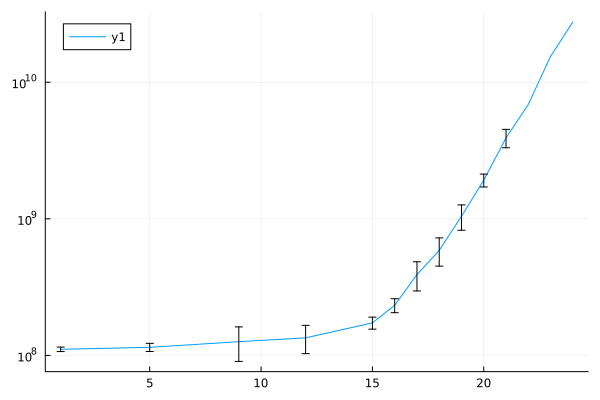

In [ ]:
Plots.plot(Ns,Ts,yerr = errs,yscale=:log10)

In [7]:
using LsqFit, Statistics

model(N, p) = p[1] .* (2 .^N) .+ p[2]

p0 = [1.0, 1e8]  # initial guess for [a, b]



fit = LsqFit.curve_fit(model, Ns, Ts, p0,inplace=false)

params = coef(fit)
errors = stderror(fit)

println("a = $(params[1]) ± $(errors[1])")
println("b = $(params[2]) ± $(errors[2])")



a = 1667.2600877444165 ± 24.632359368787153
b = 1.9800980530866995e8 ± 1.2753549178830566e8


In [9]:
Plots.plot(Ns,Ts,yerr = errs,yscale=:log10,label="Data")
Plots.plot!(Ns,model(Ns,params),yscale=:log10,label = "Exponential Model")
savefig("../Images/TreeGrowth.png")

"c:\\Users\\Ivan\\Desktop\\Stuff4School\\Thesis\\CleanDTFE\\Images\\TreeGrowth.png"

# Estimator Lookup Benchmarks

In [7]:
Ns = [1,5,9,12,15,16,17,18,19,20,21,22,23,24]
means = []
meds = []

results = []

midPoint = mean(bvh.bbox,dims=2)[:,1]

for n in Ns

    bvh,tes,tets = TesselationCore.standardEstimator(ps,n)


    bench = @benchmarkable TesselationCore.DTFE(midPoint,bvh,tets,tes)
    stats = run(bench)
    push!(meds,median(stats).time)
    push!(means,mean(stats).time)
    
    println(n)
end

1
5
9
12
15
16
17
18
19
20
21
22
23
24


In [8]:
Plots.plot(Ns,meds,label="Medians")
Plots.plot!(Ns,means,label="Means")
savefig("../Images/EstimationTime.png")

"c:\\Users\\Ivan\\Desktop\\Stuff4School\\Thesis\\CleanDTFE\\Images\\EstimationTime.png"

# Leaf Hunting

In [9]:
function countLeaves(tree)
    count = 0
    
    if typeof(tree.leftChild) == TesselationCore.Bvh.BVHLeaf
        count +=1
    else 
        count += countLeaves(tree.leftChild)
    end
    if typeof(tree.rightChild) == TesselationCore.Bvh.BVHLeaf
        count +=1
    else 
        count += countLeaves(tree.rightChild)
    end

    return count

end


countLeaves (generic function with 1 method)

In [13]:
Ns = [1,5,9,12,15,16,17,18,19,20]
leavz = []

for n in Ns

    bvh,tes,tets = TesselationCore.standardEstimator(ps,n)

    push!(leavz,countLeaves(bvh.tree))
    
    println(n)
end

1
5
9
12
15
16
17
18
19
20


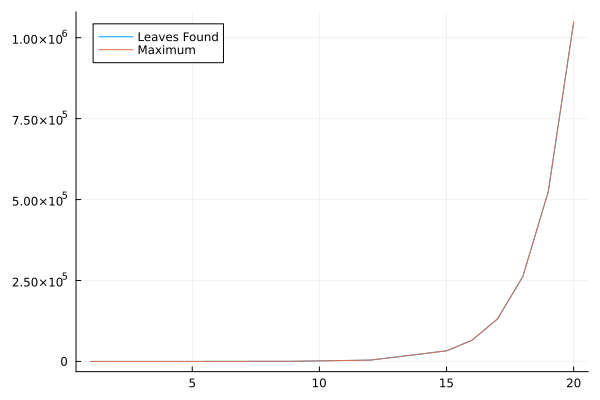

In [14]:
Plots.plot(Ns,leavz,label="Leaves Found")
Plots.plot!(Ns, 2 .^Ns,label="Maximum")

In [16]:
Plots.plot(Ns,leavz - 2 .^Ns)

savefig("../Images/Leaves.png")

"c:\\Users\\Ivan\\Desktop\\Stuff4School\\Thesis\\CleanDTFE\\Images\\Leaves.png"